# MAIN NOTEBOOK

## RESNET-18 Experimental Model Setup and Experiment

In [1]:
# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# torchvision (datasets, models, transforms)
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import models

# utilities
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


### Model Architecture

[Highlight changes made]

In [2]:
# Copy / overload of Torchvision's ResNet-18 model with necessary components
# Altered to employ proposed hierarchical self-prediction as means of regularization
from functools import partial
from typing import Any, Callable, Optional, Union

import torch
import torch.nn as nn
from torch import Tensor

from torchvision.transforms._presets import ImageClassification
from torchvision.utils import _log_api_usage_once
from torchvision.models._api import register_model, Weights, WeightsEnum
from torchvision.models._meta import _IMAGENET_CATEGORIES
from torchvision.models._utils import _ovewrite_named_param, handle_legacy_interface


__all__ = [
    "ResNet",
    "ResNet18_Weights",
    "resnet18",
]


def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class PredictionHead(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.net(x)


class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1

        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition" https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion: int = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(
        self,
        block: type[Union[BasicBlock, Bottleneck]],
        layers: list[int],
        num_classes: int = 1000,
        zero_init_residual: bool = False,
        groups: int = 1,
        width_per_group: int = 64,
        replace_stride_with_dilation: Optional[list[bool]] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        _log_api_usage_once(self)
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError(
                "replace_stride_with_dilation should be None "
                f"or a 3-element tuple, got {replace_stride_with_dilation}"
            )
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2])

        # Add self-prediction heads
        self.pred12 = PredictionHead(64 * block.expansion, 128 * block.expansion, stride=2)
        self.pred23 = PredictionHead(128 * block.expansion, 256 * block.expansion, stride=2)
        self.pred34 = PredictionHead(256 * block.expansion, 512 * block.expansion, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck) and m.bn3.weight is not None:
                    nn.init.constant_(m.bn3.weight, 0)  # type: ignore[arg-type]
                elif isinstance(m, BasicBlock) and m.bn2.weight is not None:
                    nn.init.constant_(m.bn2.weight, 0)  # type: ignore[arg-type]

    def _make_layer(
        self,
        block: type[Union[BasicBlock, Bottleneck]],
        planes: int,
        blocks: int,
        stride: int = 1,
        dilate: bool = False,
    ) -> nn.Sequential:
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(
            block(
                self.inplanes, planes, stride, downsample, self.groups, self.base_width, previous_dilation, norm_layer
            )
        )
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer,
                )
            )

        return nn.Sequential(*layers)

    def _forward_impl(self, x: Tensor, return_aux=False):
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Set up altered ResNet-18 architecture
        h1 = self.layer1(x)
        h2 = self.layer2(h1)
        h3 = self.layer3(h2)
        h4 = self.layer4(h3)

        pooled = self.avgpool(h4)
        pooled = torch.flatten(pooled, 1)
        logits = self.fc(pooled)

        if not return_aux:
            return logits

        p2 = self.pred12(h1)
        p3 = self.pred23(h2)
        p4 = self.pred34(h3)

        aux = {
            "pred12": p2,
            "target12": h2.detach(),
            "pred23": p3,
            "target23": h3.detach(),
            "pred34": p4,
            "target34": h4.detach(),
        }

        return logits, aux

    def forward(self, x: Tensor, return_aux: bool = False) -> Tensor:
        return self._forward_impl(x, return_aux=return_aux)


def _resnet(
    block: type[Union[BasicBlock, Bottleneck]],
    layers: list[int],
    weights: Optional[WeightsEnum],
    progress: bool,
    **kwargs: Any,
) -> ResNet:
    if weights is not None:
        _ovewrite_named_param(kwargs, "num_classes", len(weights.meta["categories"]))

    model = ResNet(block, layers, **kwargs)

    if weights is not None:
        model.load_state_dict(weights.get_state_dict(progress=progress, check_hash=True))

    return model


_COMMON_META = {
    "min_size": (1, 1),
    "categories": _IMAGENET_CATEGORIES,
}


class ResNet18_Weights(WeightsEnum):
    IMAGENET1K_V1 = Weights(
        url="https://download.pytorch.org/models/resnet18-f37072fd.pth",
        transforms=partial(ImageClassification, crop_size=224),
        meta={
            **_COMMON_META,
            "num_params": 11689512,
            "recipe": "https://github.com/pytorch/vision/tree/main/references/classification#resnet",
            "_metrics": {
                "ImageNet-1K": {
                    "acc@1": 69.758,
                    "acc@5": 89.078,
                }
            },
            "_ops": 1.814,
            "_file_size": 44.661,
            "_docs": """These weights reproduce closely the results of the paper using a simple training recipe.""",
        },
    )
    DEFAULT = IMAGENET1K_V1


def resnet18(*, weights: Optional[ResNet18_Weights] = None, progress: bool = True, **kwargs: Any) -> ResNet:
    """ResNet-18 from `Deep Residual Learning for Image Recognition <https://arxiv.org/abs/1512.03385>`__.

    Args:
        weights (:class:`~torchvision.models.ResNet18_Weights`, optional): The
            pretrained weights to use. See
            :class:`~torchvision.models.ResNet18_Weights` below for
            more details, and possible values. By default, no pre-trained
            weights are used.
        progress (bool, optional): If True, displays a progress bar of the
            download to stderr. Default is True.
        **kwargs: parameters passed to the ``torchvision.models.resnet.ResNet``
            base class. Please refer to the `source code
            <https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py>`_
            for more details about this class.

    .. autoclass:: torchvision.models.ResNet18_Weights
        :members:
    """
    weights = ResNet18_Weights.verify(weights)

    return _resnet(BasicBlock, [2, 2, 2, 2], weights, progress, **kwargs)


In [3]:
class CIFARResNet18(nn.Module):
    def __init__(self, num_classes=10, return_aux=False):
        """
        ResNet-18 adapted for CIFAR-10

        notable changes from the default ImageNet version:
          - the first convolution is changed from 7x7 stride 2 to 3x3 stride 1
            because CIFAR-10 images are only 32x32
          - initial max-pooling layer is removed, since aggressive early
            downsampling is not appropriate for such small inputs
          - the final fully connected layer is changed to output 10 classes
        """
        super().__init__()

        # torchvision's ResNet-18 definition
        # weights=None means we are training from scratch
        #self.model = models.resnet18(weights=None)
        self.model = resnet18(weights=None, num_classes=num_classes)

        # replace the first convolution layer for CIFAR-sized inputs
        self.model.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # remove the initial max-pool layer
        self.model.maxpool = nn.Identity()

        # replace final classifier to align with CIFAR-10's 10 classes
        self.model.fc = nn.Linear(
            in_features=self.model.fc.in_features,
            out_features=num_classes
        )

    def forward(self, x, return_aux=False):
        """
        Forward pass through the adapted ResNet-18.
        """
        return self.model(x, return_aux=return_aux)

In [4]:
# check the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CIFARResNet18(num_classes=10).to(device)
print(model)

Using device: cuda
CIFARResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inp

### Data and Dataloaders
The same data and dataloaders will be used for both experiments (unchanged model vs the forward prediction layer model) and results will be compared.


In [5]:
# CIFAR-10 train transform with common augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

# Test transform should not include augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

In [6]:
# Define CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
) # 50k images


# Define CIFAR-10 test dataset
testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
) # 10k images


100%|██████████| 170M/170M [00:06<00:00, 25.6MB/s]


In [7]:
NUM_WORKERS = 2 # num_workers > 0 usually helps in Colab
BATCH_SIZE = 128

from torch.utils.data import random_split

train_size = int(0.9 * len(trainset))  # 45k
val_size = len(trainset) - train_size  # 5k

train_subset, val_subset = random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda") # pin_memory helps when transferring CPU batches to GPU
)

valloader = torch.utils.data.DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda") # pin_memory helps when transferring CPU batches to GPU
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

#### CIFAR-10-C located in my google drive (colab use)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

# add your own personal path here
cifar10c_root = "/content/drive/MyDrive/school/cs512/CIFAR-10-C"

labels_path = os.path.join(cifar10c_root, "labels.npy")

Mounted at /content/drive


### Model training parameters and training loop

Includes using Cross Entropy Loss and the SGD optimizer, which are standards for this dataset.

In [10]:
model = CIFARResNet18(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

# standard setup for ResNet on CIFAR-10
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 20],
    gamma=0.1
)

# Mixed precision scaler for faster CUDA training in Colab
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

In [11]:
NUM_EPOCHS = 25

# optimization for fixed-size inputs like CIFAR-10
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

# save at each epoch for plots
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# save best model
best_val_acc = 0.0

# lam12 = 0.001
# lam23 = 0.001
# lam34 = 0.001

lam = 0.001 # found as best lambda

# Training + validation loop
for epoch in range(1, NUM_EPOCHS + 1):

    #
    # Training phase
    #
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    print("=" * 40)
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print("=" * 40)

    for batch_idx, (images, labels) in enumerate(trainloader, 1):
        # move batch to GPU/CPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # mixed precision forward pass on CUDA
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):

            logits, aux = model(images, return_aux=True)
            loss_ce = criterion(logits, labels)

            loss12 = F.mse_loss(aux["pred12"], aux["target12"])
            loss23 = F.mse_loss(aux["pred23"], aux["target23"])
            loss34 = F.mse_loss(aux["pred34"], aux["target34"])

            # loss = loss_ce + lam(loss12 + loss23 + loss34)
            loss = loss_ce + lam * (loss12 + loss23 + loss34)


        # backprop with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # store results
        running_train_loss += loss.item()
        _, predicted = logits.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

        # print status
        if batch_idx % 50 == 0 or batch_idx == len(trainloader):
            print(
                f"Batch {batch_idx:3d}/{len(trainloader)} "
                f"| Loss: {loss.item():.4f}"
            )

    avg_train_loss = running_train_loss / len(trainloader)
    train_acc = 100.0 * correct_train / total_train

    #
    # val phase
    #
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # store results
            running_val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    avg_val_loss = running_val_loss / len(valloader)
    val_acc = 100.0 * correct_val / total_val

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "best_model.pth")

    print("-" * 40)
    print(f"Epoch {epoch} Summary")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Validation Loss : {avg_val_loss:.4f}")
    print(f"Validation Acc  : {val_acc:.2f}%")
    print(f"LR        : {current_lr:.5f}")
    print("-" * 40)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

EPOCH 1/25
Batch  50/352 | Loss: 2.3441
Batch 100/352 | Loss: 2.0633
Batch 150/352 | Loss: 2.0047
Batch 200/352 | Loss: 1.7935
Batch 250/352 | Loss: 1.7589
Batch 300/352 | Loss: 1.6178
Batch 350/352 | Loss: 1.7082
Batch 352/352 | Loss: 1.7370
----------------------------------------
Epoch 1 Summary
Train Loss: 2.0779
Train Acc : 26.07%
Validation Loss : 1.6832
Validation Acc  : 37.64%
LR        : 0.10000
----------------------------------------
EPOCH 2/25
Batch  50/352 | Loss: 1.5545
Batch 100/352 | Loss: 1.5652
Batch 150/352 | Loss: 1.3562
Batch 200/352 | Loss: 1.2829
Batch 250/352 | Loss: 1.3157
Batch 300/352 | Loss: 1.3070
Batch 350/352 | Loss: 1.1367
Batch 352/352 | Loss: 1.3442
----------------------------------------
Epoch 2 Summary
Train Loss: 1.4683
Train Acc : 45.68%
Validation Loss : 1.3407
Validation Acc  : 51.24%
LR        : 0.10000
----------------------------------------
EPOCH 3/25
Batch  50/352 | Loss: 1.2906
Batch 100/352 | Loss: 1.2369
Batch 150/352 | Loss: 1.2884
Batc

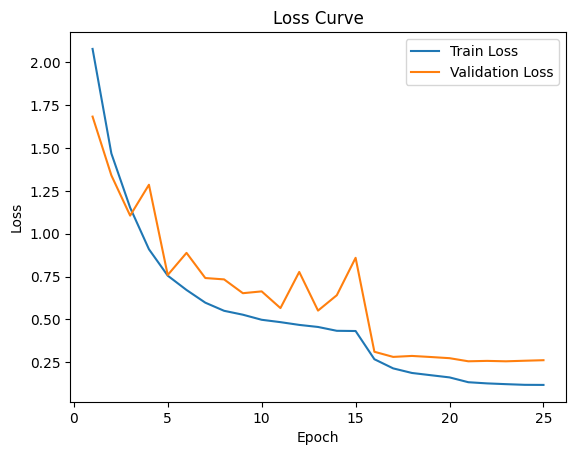

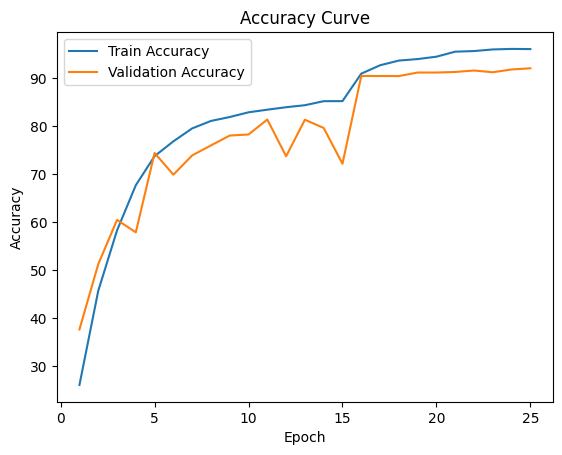

In [12]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

### Test Results for CIFAR-10

In [13]:
# ============================================
# Final test evaluation on held-out test set
# ============================================

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_test_loss += loss.item()
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()

avg_test_loss = running_test_loss / len(testloader)
test_acc = 100.0 * correct_test / total_test

print("=" * 40)
print("FINAL TEST RESULTS")
print("=" * 40)
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("=" * 40)

FINAL TEST RESULTS
Test Loss: 0.2513
Test Accuracy: 91.67%


### Test results for CIFAR-10-C

Wrapper class to handle the different corruption types and severities

In [14]:
# dataset wrapper for one corruption and one severity
class CIFAR10CDataset(Dataset):
    """
    Wrapper for a single CIFAR-10-C corruption file at a chosen severity level.

    Each corruption .npy file contains 50,000 images total:
      - severity 1: indices 0 to 9999
      - severity 2: indices 10000 to 19999
      - severity 3: indices 20000 to 29999
      - severity 4: indices 30000 to 39999
      - severity 5: indices 40000 to 49999

    labels.npy contains the matching 10,000 CIFAR-10 test labels.
    """

    def __init__(self, data_path, labels_path, severity=1, transform=None):
        assert 1 <= severity <= 5, "severity must be between 1 and 5"

        self.transform = transform

        data = np.load(data_path)      # usually shape: (50000, 32, 32, 3)
        labels = np.load(labels_path)  # can be 10000 or 50000 depending on package version

        start = (severity - 1) * 10000
        end = severity * 10000

        # Slice the corruption images for the requested severity
        self.data = data[start:end]

        # Handle either possible label-file format safely
        if len(labels) == 50000:
            self.labels = labels[start:end]
        elif len(labels) == 10000:
            self.labels = labels
        else:
            raise ValueError(f"Unexpected labels.npy length: {len(labels)}")

        # Safety check
        assert len(self.data) == len(self.labels), (
            f"Data/label length mismatch: {len(self.data)} images vs {len(self.labels)} labels"
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        label = int(self.labels[idx])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

Transform object and helper

In [15]:
# test-time
cifar10c_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

def evaluate_model_on_loader(model, loader, criterion, device):
    """
    Evaluate a trained model on a dataloader and return:
      - average loss
      - accuracy
      - error
    """
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Use mixed precision only when CUDA is available
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    error = 100.0 - accuracy

    return avg_loss, accuracy, error

Perform tests using best model

In [16]:
# load best saved model before corruption testing
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
print("loaded best_model.pth")


# CIFAR-10-C corruption types
# TODO: CAN PICK ONLY SOME OF THESE NOT ALL LATER
corruptions = [
    "gaussian_noise",
    "shot_noise",
    "impulse_noise",
    "defocus_blur",
    "glass_blur",
    "motion_blur",
    "zoom_blur",
    "snow",
    "frost",
    "fog",
    "brightness",
    "contrast",
    "elastic_transform",
    "pixelate",
    "jpeg_compression",
    "speckle_noise",
    "gaussian_blur",
    "spatter",
    "saturate"
]


# evaluate each corruption at severity levels 1 through 5
results = []

for corruption in corruptions:
    corruption_path = os.path.join(cifar10c_root, f"{corruption}.npy")
    assert os.path.exists(corruption_path), f"Missing corruption file: {corruption_path}"

    severity_losses = []
    severity_accuracies = []
    severity_errors = []

    print("=" * 60)
    print(f"Evaluating corruption: {corruption}")
    print("=" * 60)

    for severity in range(1, 6):
        dataset = CIFAR10CDataset(
            data_path=corruption_path,
            labels_path=labels_path,
            severity=severity,
            transform=cifar10c_transform
        )

        loader = DataLoader(
            dataset,
            batch_size=128,
            shuffle=False,
            num_workers=2,
            pin_memory=(device.type == "cuda")
        )

        avg_loss, accuracy, error = evaluate_model_on_loader(
            model=model,
            loader=loader,
            criterion=criterion,
            device=device
        )

        severity_losses.append(avg_loss)
        severity_accuracies.append(accuracy)
        severity_errors.append(error)

        print(
            f"Severity {severity} | "
            f"Loss: {avg_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}% | "
            f"Error: {error:.2f}%"
        )

    corruption_avg_loss = float(np.mean(severity_losses))
    corruption_avg_acc = float(np.mean(severity_accuracies))
    corruption_avg_err = float(np.mean(severity_errors))

    results.append({
        "corruption": corruption,
        "avg_loss": corruption_avg_loss,
        "avg_accuracy": corruption_avg_acc,
        "avg_error": corruption_avg_err,
        "severity_1_acc": severity_accuracies[0],
        "severity_2_acc": severity_accuracies[1],
        "severity_3_acc": severity_accuracies[2],
        "severity_4_acc": severity_accuracies[3],
        "severity_5_acc": severity_accuracies[4],
    })

    print("-" * 60)
    print(f"{corruption} average across severities")
    print(f"Avg Loss     : {corruption_avg_loss:.4f}")
    print(f"Avg Accuracy : {corruption_avg_acc:.2f}%")
    print(f"Avg Error    : {corruption_avg_err:.2f}%")
    print("-" * 60)


# convert results to a dataframe for easier viewing
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="avg_accuracy", ascending=False).reset_index(drop=True)

print("\nPer-corruption summary:")
print(results_df)


# compute overall robustness statistics
overall_avg_accuracy = float(results_df["avg_accuracy"].mean())
overall_avg_error = float(results_df["avg_error"].mean())

severity_summary = {
    "severity_1_avg_acc": float(results_df["severity_1_acc"].mean()),
    "severity_2_avg_acc": float(results_df["severity_2_acc"].mean()),
    "severity_3_avg_acc": float(results_df["severity_3_acc"].mean()),
    "severity_4_avg_acc": float(results_df["severity_4_acc"].mean()),
    "severity_5_avg_acc": float(results_df["severity_5_acc"].mean()),
}

print("\n" + "=" * 60)
print("CIFAR-10-C ROBUSTNESS SUMMARY")
print("=" * 60)
print(f"Average Corruption Accuracy: {overall_avg_accuracy:.2f}%")
print(f"Average Corruption Error   : {overall_avg_error:.2f}%")
print("-" * 60)
print("Average Accuracy by Severity")
print(f"Severity 1: {severity_summary['severity_1_avg_acc']:.2f}%")
print(f"Severity 2: {severity_summary['severity_2_avg_acc']:.2f}%")
print(f"Severity 3: {severity_summary['severity_3_avg_acc']:.2f}%")
print(f"Severity 4: {severity_summary['severity_4_avg_acc']:.2f}%")
print(f"Severity 5: {severity_summary['severity_5_avg_acc']:.2f}%")
print("=" * 60)


# ---------------------------------------------------------
# 10. Optional: save results to CSV for your report
# ---------------------------------------------------------
results_df.to_csv("cifar10c_results.csv", index=False)
print("\nSaved per-corruption results to cifar10c_results.csv")

loaded best_model.pth
Evaluating corruption: gaussian_noise
Severity 1 | Loss: 0.8066 | Accuracy: 76.87% | Error: 23.13%
Severity 2 | Loss: 1.7987 | Accuracy: 55.88% | Error: 44.12%
Severity 3 | Loss: 2.9911 | Accuracy: 37.31% | Error: 62.69%
Severity 4 | Loss: 3.5163 | Accuracy: 31.09% | Error: 68.91%
Severity 5 | Loss: 3.9892 | Accuracy: 26.16% | Error: 73.84%
------------------------------------------------------------
gaussian_noise average across severities
Avg Loss     : 2.6204
Avg Accuracy : 45.46%
Avg Error    : 54.54%
------------------------------------------------------------
Evaluating corruption: shot_noise
Severity 1 | Loss: 0.5145 | Accuracy: 83.71% | Error: 16.29%
Severity 2 | Loss: 0.9057 | Accuracy: 74.60% | Error: 25.40%
Severity 3 | Loss: 2.1243 | Accuracy: 51.02% | Error: 48.98%
Severity 4 | Loss: 2.6621 | Accuracy: 42.39% | Error: 57.61%
Severity 5 | Loss: 3.5361 | Accuracy: 31.20% | Error: 68.80%
------------------------------------------------------------
shot_n

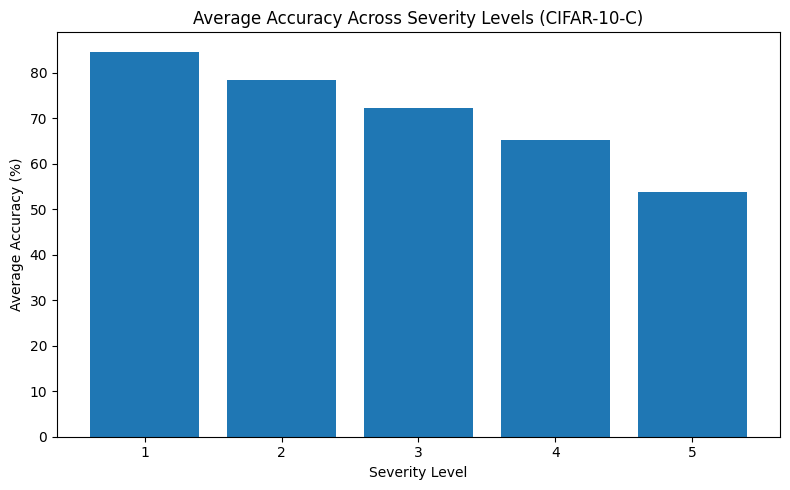

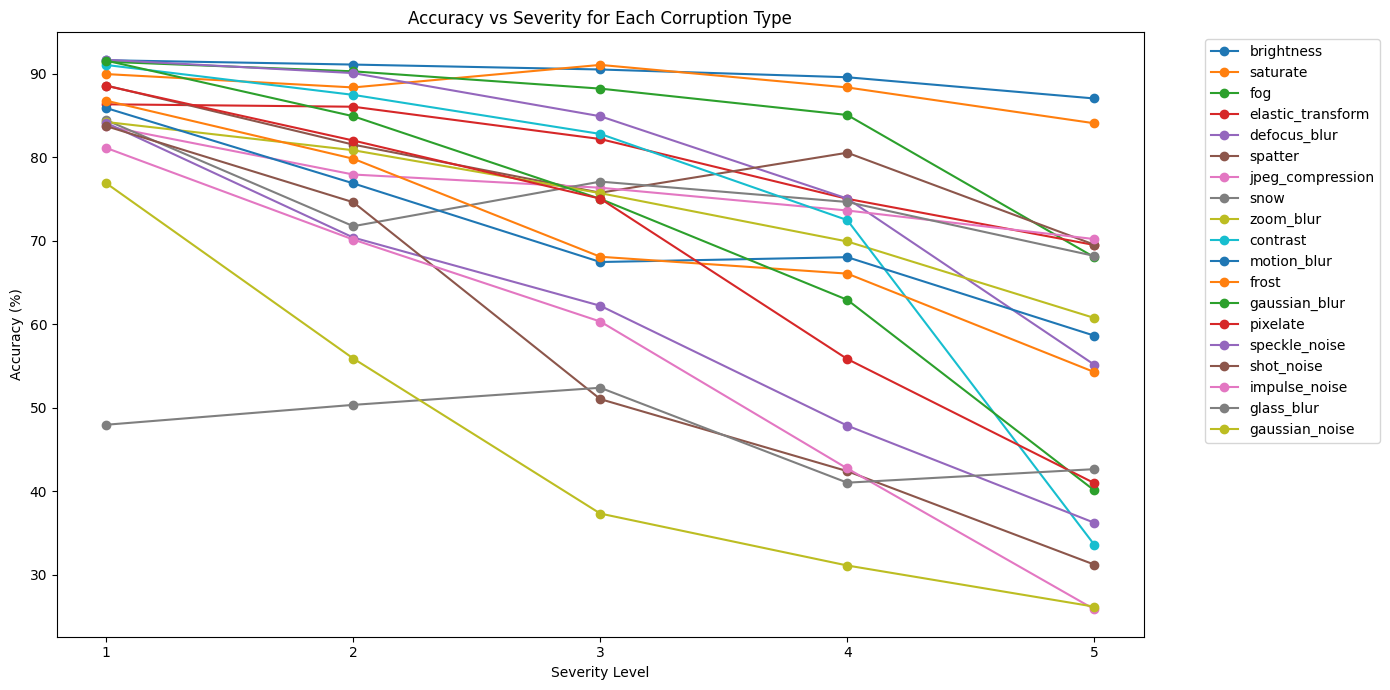

In [17]:
# produce summary plots for base model and corruption data

import matplotlib.pyplot as plt

# BAR GRAPH: average accuracy across severity levels (general)

severity_levels = [1, 2, 3, 4, 5]

avg_severity_acc = [
    severity_summary["severity_1_avg_acc"],
    severity_summary["severity_2_avg_acc"],
    severity_summary["severity_3_avg_acc"],
    severity_summary["severity_4_avg_acc"],
    severity_summary["severity_5_avg_acc"],
]

plt.figure(figsize=(8, 5))

plt.bar(severity_levels, avg_severity_acc)

plt.xlabel("Severity Level")
plt.ylabel("Average Accuracy (%)")
plt.title("Average Accuracy Across Severity Levels (CIFAR-10-C)")
plt.xticks(severity_levels)
plt.tight_layout()
plt.show()

# LINE PLOT: each corruption across severities

severity_cols = [
    "severity_1_acc",
    "severity_2_acc",
    "severity_3_acc",
    "severity_4_acc",
    "severity_5_acc"
]

plt.figure(figsize=(14, 7))

for _, row in results_df.iterrows():
    accuracies = [row[col] for col in severity_cols]

    plt.plot(
        severity_levels,
        accuracies,
        marker="o",
        label=row["corruption"]
    )

plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Severity for Each Corruption Type")
plt.xticks(severity_levels)

# move legend outside so it doesn't destroy readability
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()